# 03 Detection & Segmentation：目标检测与语义分割入门

> 前置：`01-cnn-basics`（卷积、池化）。
> 目标：理解"分类 → 定位 → 检测 → 分割"的任务谱系；动手实现 IoU、NMS 这两个检测核心算法；训练一个微型 U-Net 做语义分割。

## 任务谱系

| 任务 | 输出 | 代表模型 |
|---|---|---|
| 图像分类 | 1 个标签 | CNN / ViT |
| 目标检测 | 多个框 (x,y,w,h) + 每框类别 | Faster R-CNN / YOLO |
| 实例分割 | 每个实例的像素级掩码 | Mask R-CNN |
| 语义分割 | 每个像素的类别 | U-Net / DeepLab |

本课聚焦两个最通用的积木：**IoU（交并比）**与**NMS（非极大值抑制）**，然后完整训练一个分割模型。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. IoU：框与框的重合度

$$\text{IoU} = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{交集面积}}{\text{交集面积} + \text{并集面积}}$$

- IoU=1：完全重合；IoU=0：不相交。检测里通常 IoU>0.5 视为"检测到同一个目标"。

In [2]:
def box_area(b):
    return max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])

def iou(b1, b2):
    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    union = box_area(b1) + box_area(b2) - inter
    return inter / union if union > 0 else 0.0

# 手工验算：两个 3×3 框，平移 1 格重叠
b1 = [0, 0, 3, 3]; b2 = [1, 1, 4, 4]
print(f"重叠 2×2=4，并集 9+9-4=14 → IoU = {4/14:.4f}，程序 = {iou(b1, b2):.4f}")
print(f"完全重合 IoU = {iou([0,0,3,3],[0,0,3,3]):.1f}")
print(f"不相交 IoU = {iou([0,0,1,1],[5,5,6,6]):.1f}")

重叠 2×2=4，并集 9+9-4=14 → IoU = 0.2857，程序 = 0.2857
完全重合 IoU = 1.0
不相交 IoU = 0.0


## 2. NMS：去掉重复框

检测器会输出**大量重叠的候选框**（一个目标十几个框）。NMS 流程：

1. 按置信度从高到低排序；
2. 保留最高分框，删掉与它 IoU > 阈值的框；
3. 对剩余框重复，直到没有框。

In [3]:
def nms(boxes, scores, thresh=0.5):
    order = np.argsort(-scores)
    keep = []
    while order.size:
        i = int(order[0]); keep.append(i)
        rest = order[1:]
        if rest.size:
            ious = np.array([iou(boxes[i], boxes[j]) for j in rest])
            order = rest[ious <= thresh]
        else:
            break
    return keep

boxes = np.array([[0,0,4,4],[1,1,5,5],[0.2,0.2,3.8,3.8],[10,10,13,13],[9,9,14,14]], dtype=float)
scores = np.array([0.9, 0.75, 0.8, 0.6, 0.95])
keep = nms(boxes, scores, 0.5)
print("保留的框序号:", keep, "（0.8 分框与 0.9 分框 IoU≈0.81 被删；0.75 分框与 0.9 分框 IoU≈0.39 保留）")

保留的框序号: [4, 0, 1, 3] （0.8 分框与 0.9 分框 IoU≈0.81 被删；0.75 分框与 0.9 分框 IoU≈0.39 保留）


## 3. 语义分割：微型 U-Net

U-Net（2015）是分割的标准骨架，核心是**编码器-解码器 + 跳跃连接**：

- **编码器**：卷积+下采样，把 16×16 压到 4×4，特征越来越"语义"；
- **解码器**：转置卷积上采样，把特征图放大回 16×16；
- **跳跃连接**：把编码器同尺寸特征拼到解码器——**把位置细节带回语义特征**（纯上采样会丢失边界）。

训练数据：16×16 灰度图，图上两个高斯亮斑，分割目标 = 左斑的像素掩码。

输入: (600, 1, 16, 16) 掩码: (600, 1, 16, 16)


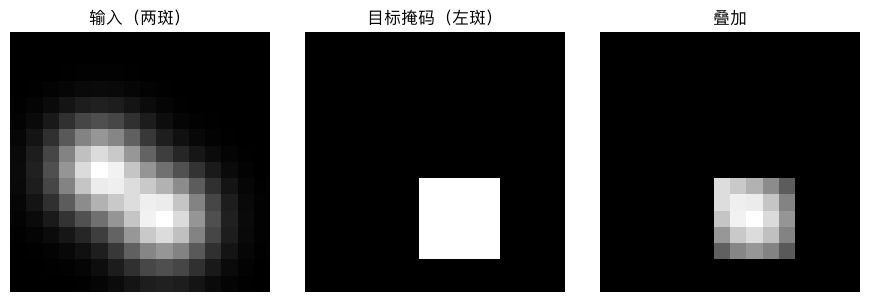

In [4]:
def make_seg_samples(n=600, seed=0):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, 16, 16)); M = np.zeros((n, 1, 16, 16))
    for s in range(n):
        c1 = rng.integers(3, 13, size=2); c2 = rng.integers(3, 13, size=2)
        for i in range(16):
            for j in range(16):
                d1 = math.sqrt((i - c1[0])**2 + (j - c1[1])**2)
                d2 = math.sqrt((i - c2[0])**2 + (j - c2[1])**2)
                X[s, 0, i, j] = math.exp(-d1**2 / 8) + math.exp(-d2**2 / 8)
                M[s, 0, i, j] = 1.0 if d1 < 3.0 else 0.0
    return X, M

Xseg, Mseg = make_seg_samples()
print("输入:", Xseg.shape, "掩码:", Mseg.shape)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(Xseg[0, 0], cmap="gray"); axes[0].set_title("输入（两斑）"); axes[0].axis("off")
axes[1].imshow(Mseg[0, 0], cmap="gray"); axes[1].set_title("目标掩码（左斑）"); axes[1].axis("off")
axes[2].imshow(Xseg[0, 0] * Mseg[0, 0], cmap="gray"); axes[2].set_title("叠加"); axes[2].axis("off")
plt.tight_layout(); plt.show()

In [5]:
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(8, 16, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        self.mid = nn.Sequential(nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(16, 16, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())   # 32 = 16(上采样) + 16(跳跃)
        self.up1 = nn.ConvTranspose2d(16, 8, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(16, 8, 3, padding=1), nn.ReLU())    # 16 = 8 + 8
        self.head = nn.Conv2d(8, 1, 1)
    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)        # 16×16 → 8×8
        e2 = self.enc2(p1); p2 = self.pool2(e2)       # 8×8 → 4×4
        m = self.mid(p2)
        u2 = self.up2(m); d2 = self.dec2(torch.cat([u2, e2], 1))   # 跳跃: e2
        u1 = self.up1(d2); d1 = self.dec1(torch.cat([u1, e1], 1))  # 跳跃: e1
        return self.head(d1)                          # 16×16 单通道 logit

model = TinyUNet()
print("U-Net 参数量:", sum(p.numel() for p in model.parameters()))

U-Net 参数量: 10921


In [6]:
Xseg_t = torch.tensor(Xseg, dtype=torch.float32); Mseg_t = torch.tensor(Mseg)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
n = len(Xseg_t)
for step in range(800):
    idx = torch.randint(0, n, (32,))
    opt.zero_grad()
    pred = model(Xseg_t[idx])
    loss = F.binary_cross_entropy_with_logits(pred, Mseg_t[idx])
    loss.backward(); opt.step()
    if step % 200 == 0:
        with torch.no_grad():
            acc = ((torch.sigmoid(pred) > 0.5).float() == Mseg_t[idx]).float().mean().item()
        print(f"step {step:4d}  loss = {loss.item():.4f}  像素准确率 = {acc:.3f}")

step    0  loss = 0.8033  像素准确率 = 0.098


step  200  loss = 0.1534  像素准确率 = 0.913


step  400  loss = 0.1462  像素准确率 = 0.913


step  600  loss = 0.1352  像素准确率 = 0.917


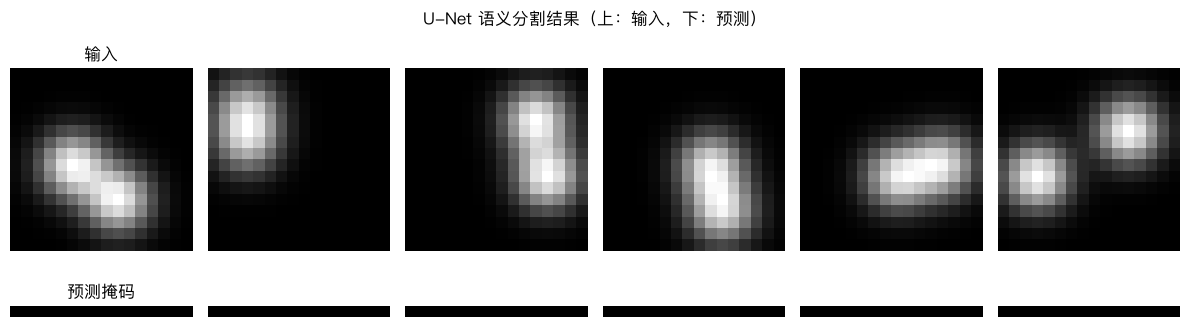

In [7]:
with torch.no_grad():
    probs = torch.sigmoid(model(Xseg_t[:6]))[..., 0].numpy()
    preds = (probs > 0.5).astype(float)

fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for i in range(6):
    axes[0, i].imshow(Xseg[i, 0], cmap="gray"); axes[0, i].set_title("输入" if i == 0 else ""); axes[0, i].axis("off")
    axes[1, i].imshow(preds[i], cmap="gray"); axes[1, i].set_title("预测掩码" if i == 0 else ""); axes[1, i].axis("off")
plt.suptitle("U-Net 语义分割结果（上：输入，下：预测）")
plt.tight_layout(); plt.show()

## 4. 总结

- **检测两件套**：IoU 定义匹配质量，NMS 去除冗余框——所有检测模型（R-CNN/YOLO 系）的训练与后处理都围绕它们。
- **分割的钥匙**：编码器-解码器结构恢复空间分辨率，跳跃连接恢复细节。U-Net 是医学影像分割的事实标准。
- **任务递进**：分类 → 检测（框）→ 分割（像素）。检测可视为"稀疏的分割"，分割可视为"稠密的检测"。

## 课后练习

1. 把 NMS 阈值从 0.5 调到 0.3 和 0.8，观察保留框数量变化，解释"误删"与"漏删"的权衡。
2. 去掉 U-Net 的跳跃连接（dec2/dec1 只接上采样输出），训练对比像素准确率——验证"细节靠跳跃连接"。
3. 把掩码目标改成"两斑都要"（并集），重新训练，观察二分类变为三分类（背景/斑1/斑2）的效果。